In [4]:
from firedrake import *
from numpy import linspace
import matplotlib.pyplot as plt
from firedrake.pyplot import plot

In [1]:
n = 100
mesh = UnitSquareMesh(n, n)

NameError: name 'UnitSquareMesh' is not defined

In [6]:
nu = Constant(1e-2)


In [7]:
V = FunctionSpace(mesh, "Lagrange", 2)
u_n1 = Function(V, name="u^{n+1}")
u_n = Function(V, name="u^{n}")
v = TestFunction(V)

In [8]:
u_n.interpolate(u_init)
dt = 1.0 / n

In [9]:
F = (((u_n1 - u_n)/dt) * v +
     u_n1 * u_n1.dx(0) * v + 
     nu*u_n1.dx(0)*v.dx(0))*dx

In [10]:
# If passed an existing Function object, the Function 
# constructor makes a copy.
results = [Function(u_n)]

problem = NonlinearVariationalProblem(F, u_n1)
solver = NonlinearVariationalSolver(problem)


In [11]:
t_end=3
for t in ProgressBar("Time step").iter(linspace(0.0, t_end, int(t_end/dt))):
    solver.solve()
    u_n.assign(u_n1)
    results.append(Function(u_n))


Time step ▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣▣ 300/300 [0:00:00]


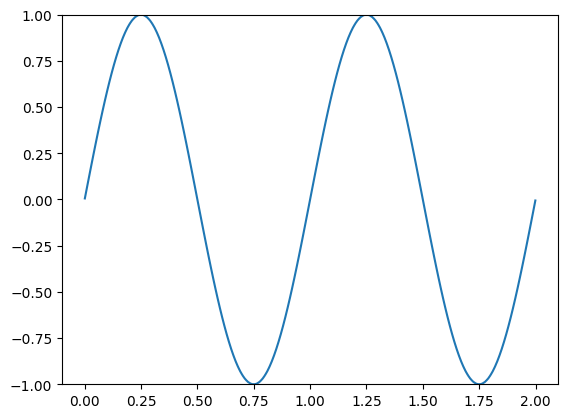

In [12]:
fig, axes = plt.subplots()
axes.set_ylim((-1., 1.))
plot(results[0], axes=axes)

In [13]:
from matplotlib.animation import FuncAnimation

def animate(u):
    axes.clear()
    plot(u, axes=axes)
    axes.set_ylim((-1., 1.))

interval = 4e3 * float(dt)
animation = FuncAnimation(fig, animate, frames=results, interval=interval)

from IPython.display import HTML
HTML(animation.to_jshtml())
